# Identifying Inconsistent Suppliers & Supply Chain Risk Tiers

Objective: identify suppliers whose performance is **inconsistent** (unpredictable, not just "bad"), and segment all suppliers into actionable **risk tiers** using unsupervised clustering on delay history and performance - so procurement/ops can prioritize mitigation instead of treating every supplier the same.

Approach:
1. Aggregate shipment-level data up to one row per **supplier** (this dataset has 1,000 suppliers, ~50 shipments each - enough per-supplier history to measure both average performance and its volatility over time).
2. Build features covering both **level** (how risky, on average) and **consistency** (how volatile over time) - the two axes the objective explicitly asks for.
3. **K-Means clustering** on standardized supplier features to assign data-driven risk tiers (k chosen via elbow + silhouette, not guessed).
4. Separately flag the **most inconsistent** suppliers (high month-to-month delay-rate volatility) - this is a different axis from "high average risk" and deserves its own list, since an inconsistent supplier needs a different response (investigate root cause) than a consistently poor one (renegotiate or replace).
5. Translate tiers + inconsistency flags into concrete supply-chain actions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_main = pd.read_csv(r"C:\Users\thiru\Downloads\GFS_Project_Horizon.csv")
df_delay = pd.read_csv(r"C:\Users\thiru\Downloads\delay_labels.csv")
df = pd.merge(df_main, df_delay, on="shipment_id")
df['shipment_date'] = pd.to_datetime(df['shipment_date'], dayfirst=True, errors='coerce')

print("Merged shape:", df.shape)
print("Unique suppliers:", df['supplier_id'].nunique())
print("Shipments per supplier:\n", df.groupby('supplier_id').size().describe())

Merged shape: (50500, 40)
Unique suppliers: 1000
Shipments per supplier:
 count    1000.000000
mean       50.500000
std         7.029895
min        28.000000
25%        46.000000
50%        50.000000
75%        55.000000
max        74.000000
dtype: float64


## Cleaning (reused from `Final Code.ipynb`)

In [2]:
df_fe = df.copy()

df_fe['supplier_region'] = (
    df_fe['supplier_region']
    .str.strip()
    .str.upper()
    .replace({'N': 'NORTH'})
    .str.title()
)

# NOTE: supplier_region varies *within* every single supplier_id in this data (checked: all
# 1,000 suppliers span more than one region label) - so it behaves like a per-shipment/route
# attribute, not a stable supplier identity. It's used below only as a descriptive label (most
# common region per supplier), never as a hard grouping key.
print(df_fe['supplier_region'].value_counts())

supplier_region
North    14084
West     12347
South    12107
East     11962
Name: count, dtype: int64


In [3]:
missing_cols = ['vehicle_age_years', 'rainfall_mm', 'supplier_rating']
for col in missing_cols:
    if df_fe[col].dtype in ['float64', 'int64']:
        df_fe[col] = df_fe[col].fillna(df_fe[col].median())
    else:
        df_fe[col] = df_fe[col].fillna(df_fe[col].mode()[0])

df_fe['shipment_month'] = df_fe['shipment_date'].dt.month
df_fe['shipment_year'] = df_fe['shipment_date'].dt.year
df_fe['year_month'] = df_fe['shipment_year'].astype(str) + '-' + df_fe['shipment_month'].astype(str).str.zfill(2)

print("Remaining missing values:", df_fe[missing_cols].isna().sum().sum())
print("Distinct year-month periods in the data:", df_fe['year_month'].nunique())

Remaining missing values: 0
Distinct year-month periods in the data: 37


## Aggregating to Supplier-Level Profiles

One row per supplier, covering both **level** (average performance) and **consistency** (volatility over time) metrics.

In [4]:
supplier_profile = df_fe.groupby('supplier_id').agg(
    n_shipments=('shipment_id', 'count'),
    delay_rate=('delay_flag', 'mean'),
    avg_penalty_cost=('penalty_cost', 'mean'),
    total_penalty_cost=('penalty_cost', 'sum'),
    avg_transportation_cost=('transportation_cost', 'mean'),
    avg_route_risk_score=('route_risk_score', 'mean'),
    avg_supplier_rating=('supplier_rating', 'mean'),
    rating_volatility=('supplier_rating', 'std'),
    most_common_region=('supplier_region', lambda s: s.mode().iloc[0]),
)

print("Supplier profile shape:", supplier_profile.shape)
supplier_profile.describe()

Supplier profile shape: (1000, 9)


,n_shipments,delay_rate,avg_penalty_cost,total_penalty_cost,avg_transportation_cost,avg_route_risk_score,avg_supplier_rating,rating_volatility
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,50.500000,0.153301,810.414946,40895.216028,17537.115841,50.028594,79.936597,9.270987
std,7.029895,0.050054,302.005739,16118.191853,1458.256028,4.355882,1.291267,0.986467
min,28.000000,0.023256,144.866716,7677.935946,11903.412461,34.521739,76.098170,6.303225
25%,46.000000,0.117647,592.116456,28933.906406,16578.464388,47.283435,79.097033,8.620074
50%,50.000000,0.148148,779.880939,39187.908654,17511.625377,49.957323,79.935267,9.252518
75%,55.000000,0.185185,1014.714358,51480.015848,18538.843226,52.829911,80.769687,9.906733
max,74.000000,0.324324,1765.985025,94509.109050,22297.383980,64.142857,84.180926,12.399123


In [5]:
# --- Temporal inconsistency: how much does this supplier's monthly delay rate swing around? ---
# A supplier that's sometimes great and sometimes terrible has a HIGH std here even if their
# overall average delay_rate looks moderate - that's exactly the "inconsistent" signal a simple
# average would miss.
monthly_delay_rate = df_fe.groupby(['supplier_id', 'year_month'])['delay_flag'].mean()
delay_rate_std_over_time = monthly_delay_rate.groupby('supplier_id').std()
months_covered = df_fe.groupby('supplier_id')['year_month'].nunique()

supplier_profile['delay_rate_std_over_time'] = delay_rate_std_over_time
supplier_profile['months_covered'] = months_covered
supplier_profile['delay_rate_std_over_time'] = supplier_profile['delay_rate_std_over_time'].fillna(0)

print("Months covered per supplier:\n", supplier_profile['months_covered'].describe())
print("\nSuppliers with only 1 month of data (std undefined, filled 0):",
      (supplier_profile['months_covered'] <= 1).sum())

Months covered per supplier:


 count    1000.000000
mean       27.247000
std         2.597834
min        17.000000
25%        26.000000
50%        27.000000
75%        29.000000
max        34.000000
Name: months_covered, dtype: float64

Suppliers with only 1 month of data (std undefined, filled 0): 0


In [6]:
# --- Rating-vs-actual gap: does the supplier's average self-reported/assessed rating match
# their measured on-time performance? A large positive gap = overrated (looks fine on paper,
# underperforms in practice) - a useful, different lens from raw delay_rate alone.
actual_on_time_pct = (1 - supplier_profile['delay_rate']) * 100
supplier_profile['rating_actual_gap'] = supplier_profile['avg_supplier_rating'] - actual_on_time_pct

supplier_profile[['delay_rate', 'avg_supplier_rating', 'rating_actual_gap', 'delay_rate_std_over_time']].describe()

,delay_rate,avg_supplier_rating,rating_actual_gap,delay_rate_std_over_time
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.153301,79.936597,-4.733333,0.292533
std,0.050054,1.291267,5.203324,0.064245
min,0.023256,76.098170,-17.918412,0.058407
25%,0.117647,79.097033,-8.245244,0.251828
50%,0.148148,79.935267,-5.264113,0.296829
75%,0.185185,80.769687,-1.508616,0.337877
max,0.324324,84.180926,14.441592,0.445664


## Clustering Methodology: Choosing K

Cluster on standardized features covering both risk **level** (`delay_rate`, `avg_penalty_cost`, `avg_route_risk_score`, `avg_supplier_rating`) and **consistency** (`delay_rate_std_over_time`) - `n_shipments` is deliberately excluded (it's sample size, not risk). K is chosen via the elbow method and silhouette score, not guessed.

In [7]:
from sklearn.preprocessing import StandardScaler

cluster_features = ['delay_rate', 'delay_rate_std_over_time', 'avg_penalty_cost',
                     'avg_route_risk_score', 'avg_supplier_rating']

X_cluster = supplier_profile[cluster_features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print("Clustering feature matrix:", X_scaled.shape)

Clustering feature matrix: (1000, 5)


C:\Users\thiru\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\thiru\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\thiru\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


C:\Users\thiru\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\thiru\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\thiru\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


C:\Users\thiru\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


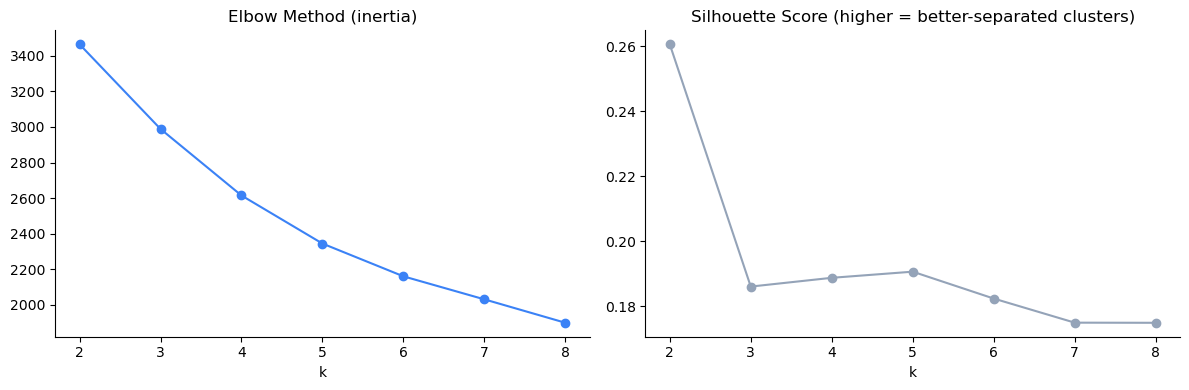

k=2: silhouette=0.2606
k=3: silhouette=0.1860
k=4: silhouette=0.1887
k=5: silhouette=0.1906
k=6: silhouette=0.1823
k=7: silhouette=0.1749
k=8: silhouette=0.1748


In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias, silhouettes = [], []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, marker='o', color='#3B82F6')
axes[0].set_title('Elbow Method (inertia)')
axes[0].set_xlabel('k')
axes[0].spines[['top', 'right']].set_visible(False)

axes[1].plot(list(k_range), silhouettes, marker='o', color='#94A3B8')
axes[1].set_title('Silhouette Score (higher = better-separated clusters)')
axes[1].set_xlabel('k')
axes[1].spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

for k, s in zip(k_range, silhouettes):
    print(f"k={k}: silhouette={s:.4f}")

In [9]:
K = 4  # chosen from the silhouette/elbow plots above - see printed scores; update if they favor a different k
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
supplier_profile['cluster'] = kmeans.fit_predict(X_scaled)

print(f"Final silhouette score at k={K}:", round(silhouette_score(X_scaled, supplier_profile['cluster']), 4))
supplier_profile.groupby('cluster')[cluster_features + ['n_shipments']].mean().round(3)

Final silhouette score at k=4: 0.1887


C:\Users\thiru\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


,delay_rate,delay_rate_std_over_time,avg_penalty_cost,avg_route_risk_score,avg_supplier_rating,n_shipments
cluster,,,,,,
0,0.219,0.354,1201.480,51.437,79.983,49.785
1,0.150,0.305,759.597,47.793,78.882,50.607
2,0.095,0.213,485.456,49.242,79.787,51.139
3,0.145,0.288,770.222,51.447,80.949,50.529


**Honest read of the silhouette scores above:** they're low across the board - best at k=2 (0.26), then flat around 0.18-0.19 from k=3 through k=8 with no sharp elbow or peak. That means suppliers sit more on a **continuum** of risk than in tightly separated natural groups - there isn't a strong data-driven signal for any particular k beyond "more than 1." k=4 is picked below for **actionability** (four named tiers give ops something to act on; two tiers would be too coarse), not because the data demands exactly 4 clusters. Treat tier *boundaries* as somewhat arbitrary; treat the *ranking* they produce (which suppliers are relatively better or worse) as the reliable part.

## Labeling Clusters as Risk Tiers

Rank cluster centroids by a composite badness score (z-scored `delay_rate` + `avg_penalty_cost` + `delay_rate_std_over_time`, minus `avg_supplier_rating`) and assign human-readable tier names - lowest composite score is the best tier.

In [10]:
centroid_z = supplier_profile.groupby('cluster')[cluster_features].mean()
centroid_z_scored = (centroid_z - X_cluster.mean()) / X_cluster.std()

badness_score = (
    centroid_z_scored['delay_rate']
    + centroid_z_scored['avg_penalty_cost']
    + centroid_z_scored['delay_rate_std_over_time']
    - centroid_z_scored['avg_supplier_rating']
).sort_values()

tier_names = ['Tier 1 - Reliable', 'Tier 2 - Stable Moderate Risk',
              'Tier 3 - Elevated Risk', 'Tier 4 - High Risk'][:K]
cluster_to_tier = dict(zip(badness_score.index, tier_names))

supplier_profile['risk_tier'] = supplier_profile['cluster'].map(cluster_to_tier)

print("Cluster -> Tier mapping (ordered by composite badness score):")
for cluster_id, score in badness_score.items():
    print(f"  cluster {cluster_id} -> {cluster_to_tier[cluster_id]}  (badness z-score: {score:+.2f})")

print()
supplier_profile.groupby('risk_tier')[cluster_features + ['n_shipments']].mean().round(3).reindex(tier_names)

Cluster -> Tier mapping (ordered by composite badness score):
  cluster 2 -> Tier 1 - Reliable  (badness z-score: -3.37)
  cluster 3 -> Tier 2 - Stable Moderate Risk  (badness z-score: -1.15)
  cluster 1 -> Tier 3 - Elevated Risk  (badness z-score: +0.77)
  cluster 0 -> Tier 4 - High Risk  (badness z-score: +3.52)



,delay_rate,delay_rate_std_over_time,avg_penalty_cost,avg_route_risk_score,avg_supplier_rating,n_shipments
risk_tier,,,,,,
Tier 1 - Reliable,0.095,0.213,485.456,49.242,79.787,51.139
Tier 2 - Stable Moderate Risk,0.145,0.288,770.222,51.447,80.949,50.529
Tier 3 - Elevated Risk,0.150,0.305,759.597,47.793,78.882,50.607
Tier 4 - High Risk,0.219,0.354,1201.480,51.437,79.983,49.785


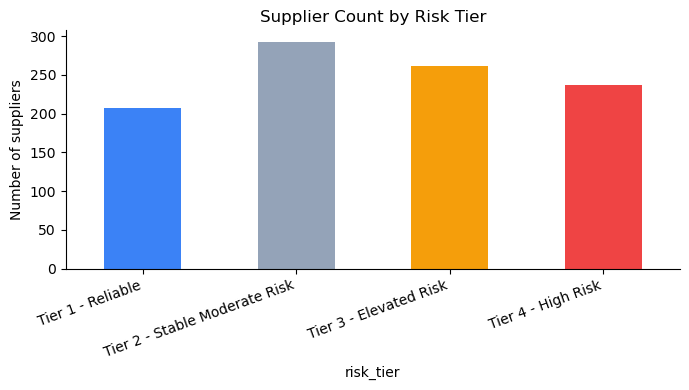

risk_tier
Tier 1 - Reliable                208
Tier 2 - Stable Moderate Risk    293
Tier 3 - Elevated Risk           262
Tier 4 - High Risk               237
Name: count, dtype: int64


In [11]:
tier_counts = supplier_profile['risk_tier'].value_counts().reindex(tier_names)

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#3B82F6', '#94A3B8', '#F59E0B', '#EF4444'][:K]
tier_counts.plot.bar(ax=ax, color=colors)
ax.set_title('Supplier Count by Risk Tier')
ax.set_ylabel('Number of suppliers')
ax.spines[['top', 'right']].set_visible(False)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()
print(tier_counts)

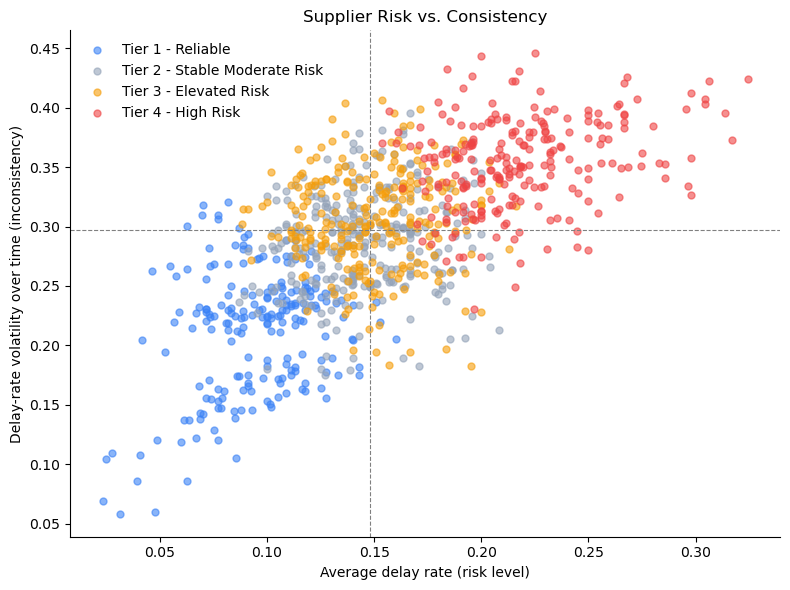

In [12]:
# --- The risk-vs-consistency quadrant: this is the chart that most directly answers the
# objective - level (x-axis) and volatility (y-axis) are different axes, and a supplier can be
# risky in either or both. ---
fig, ax = plt.subplots(figsize=(8, 6))
color_map = dict(zip(tier_names, colors))
for tier in tier_names:
    subset = supplier_profile[supplier_profile['risk_tier'] == tier]
    ax.scatter(subset['delay_rate'], subset['delay_rate_std_over_time'],
               label=tier, color=color_map[tier], alpha=0.6, s=25)

ax.axvline(supplier_profile['delay_rate'].median(), color='gray', linestyle='--', linewidth=0.8)
ax.axhline(supplier_profile['delay_rate_std_over_time'].median(), color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Average delay rate (risk level)')
ax.set_ylabel('Delay-rate volatility over time (inconsistency)')
ax.set_title('Supplier Risk vs. Consistency')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## Identifying the Most Inconsistent Suppliers

Flagged independently of risk tier - a supplier can be "inconsistent" (high `delay_rate_std_over_time`) whether their average risk tier is good or bad. Restricted to suppliers with at least 3 months of coverage, so the volatility estimate isn't just noise from too few data points.

In [13]:
eligible = supplier_profile[supplier_profile['months_covered'] >= 3]
inconsistency_threshold = eligible['delay_rate_std_over_time'].quantile(0.90)

supplier_profile['is_inconsistent'] = (
    (supplier_profile['months_covered'] >= 3)
    & (supplier_profile['delay_rate_std_over_time'] > inconsistency_threshold)
)

print(f"Inconsistency threshold (90th percentile of delay-rate volatility): {inconsistency_threshold:.4f}")
print(f"Suppliers flagged as inconsistent: {supplier_profile['is_inconsistent'].sum()} / {len(supplier_profile)}")
print()
print("Risk tier breakdown of the flagged inconsistent suppliers:")
print(supplier_profile.loc[supplier_profile['is_inconsistent'], 'risk_tier'].value_counts().reindex(tier_names).fillna(0))

supplier_profile[supplier_profile['is_inconsistent']].sort_values(
    'delay_rate_std_over_time', ascending=False
)[['risk_tier', 'delay_rate', 'delay_rate_std_over_time', 'avg_penalty_cost',
   'avg_supplier_rating', 'rating_actual_gap', 'n_shipments', 'most_common_region']].head(20)

Inconsistency threshold (90th percentile of delay-rate volatility): 0.3704
Suppliers flagged as inconsistent: 100 / 1000

Risk tier breakdown of the flagged inconsistent suppliers:
risk_tier
Tier 1 - Reliable                 0.0
Tier 2 - Stable Moderate Risk     6.0
Tier 3 - Elevated Risk           12.0
Tier 4 - High Risk               82.0
Name: count, dtype: float64


,risk_tier,delay_rate,delay_rate_std_over_time,avg_penalty_cost,avg_supplier_rating,rating_actual_gap,n_shipments,most_common_region
supplier_id,,,,,,,,
1859,Tier 4 - High Risk,0.225000,0.445664,1214.283763,81.163229,3.663229,40,North
1998,Tier 4 - High Risk,0.200000,0.443732,1085.008532,80.260125,0.260125,40,South
1432,Tier 4 - High Risk,0.184211,0.432478,1262.271841,76.980632,-4.598315,38,West
1231,Tier 4 - High Risk,0.217391,0.431084,1099.564779,80.582236,2.321366,46,South
1289,Tier 4 - High Risk,0.195652,0.426631,879.239266,78.985306,-1.449477,46,South
1868,Tier 4 - High Risk,0.267857,0.425720,1466.323493,80.504178,7.289892,56,North
1607,Tier 4 - High Risk,0.324324,0.424337,1617.976011,82.009159,14.441592,37,South
1509,Tier 4 - High Risk,0.306122,0.422662,1455.416817,78.193087,8.805332,49,East
1785,Tier 4 - High Risk,0.215686,0.422607,1169.489267,79.500185,1.068812,51,South


## Improving Supply Chain Performance: Tiered Actions

| Segment | What it means | Recommended action |
|---|---|---|
| **Tier 1 - Reliable** | Low delay rate, low volatility, low penalty cost | Preferred suppliers - route high-priority/time-sensitive shipments here first |
| **Tier 2 - Stable Moderate Risk** | Middling delay rate but *predictable* | Standard SLAs are fine; monitor routinely, no urgent action |
| **Tier 3 - Elevated Risk** | Above-average delay rate and/or penalty cost | Add schedule buffer, renegotiate SLAs, or reduce allocation for high-priority shipments |
| **Tier 4 - High Risk** | High delay rate, high volatility, high penalty cost | Formal improvement plan or supplier replacement; avoid for high-priority/high-value shipments |
| **Flagged Inconsistent** (any tier) | Performance swings month to month, regardless of average | **Different response than a consistently-bad supplier**: investigate root cause (seasonal? single bad batch? capacity spikes?) before renegotiating or replacing - a good average can hide serious intermittent failures, and a volatile supplier may just need a specific fix, not a full replacement |

The inconsistent-supplier flag is the one a pure average-based scorecard would miss entirely - that's the main gap this analysis closes versus just ranking suppliers by delay rate.

In [14]:
output_path = r"C:\Users\thiru\Downloads\supplier_risk_tiers.csv"
export_cols = ['risk_tier', 'is_inconsistent', 'n_shipments', 'delay_rate', 'delay_rate_std_over_time',
               'avg_penalty_cost', 'total_penalty_cost', 'avg_transportation_cost', 'avg_route_risk_score',
               'avg_supplier_rating', 'rating_actual_gap', 'most_common_region']
supplier_profile[export_cols].sort_values(['risk_tier', 'delay_rate_std_over_time'], ascending=[True, False]).to_csv(output_path)
print(f"Saved {output_path}")
print(f"{len(supplier_profile)} suppliers exported, columns: {export_cols}")

Saved C:\Users\thiru\Downloads\supplier_risk_tiers.csv
1000 suppliers exported, columns: ['risk_tier', 'is_inconsistent', 'n_shipments', 'delay_rate', 'delay_rate_std_over_time', 'avg_penalty_cost', 'total_penalty_cost', 'avg_transportation_cost', 'avg_route_risk_score', 'avg_supplier_rating', 'rating_actual_gap', 'most_common_region']


### Notes / caveats

- **`supplier_region` is not a stable supplier attribute in this data** - every supplier ships across multiple regions, so it's reported per supplier as the most common (mode) region for context only, never used as a hard grouping key or clustering feature.
- **`supplier_rating` is highly volatile per shipment**, even for the same supplier (within-supplier std $\approx$ population-wide std) - it reads more like a per-shipment/interaction score than a stable supplier trait. `rating_actual_gap` and `rating_volatility` are reported as supplementary context, but the primary risk signal here is the *operational* one (`delay_rate`, `delay_rate_std_over_time`, `avg_penalty_cost`), which is more defensible.
- **`avg_route_risk_score` is a confound, not a pure supplier signal** - a supplier assigned to consistently risky routes will look riskier here even if their own execution is fine. Worth cross-checking any Tier 3/4 assignment against whether it's route-driven before penalizing the supplier specifically.
- **Small-sample suppliers** (near the low end of `n_shipments`, or `months_covered` < 3) have noisier `delay_rate_std_over_time` estimates - the inconsistency flag already restricts to >=3 months covered, but tier assignment does not; treat tier labels for low-volume suppliers as lower-confidence.
- Re-run this notebook periodically (e.g., quarterly) as new shipments accumulate - both risk level and consistency are meant to be tracked over time, not computed once.